In [40]:
from langgraph.graph import StateGraph , START,END
from typing import TypedDict
from IPython.display import Image

In [41]:
#Define State
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    
    bmi: float

In [42]:
def calculate_bmi(state:BMIState)->BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    
    bmi = weight/height**2
    bmi= round(bmi,2)
    state['bmi']=bmi
    
    return {'bmi':bmi}

In [43]:
#Define a graph
graph = StateGraph(BMIState)

#add nodes
graph.add_node('calculate_bmi',calculate_bmi)


#add edges
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi',END)


#compile the graph
workflow = graph.compile()


In [44]:
#Execute the graph
initial_state = {'weight_kg':80 , 'height_m':1.73}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73}


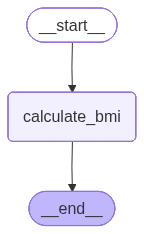

In [45]:
#Drawing the workflow
Image(workflow.get_graph().draw_mermaid_png())